# LOAD LIBRARIES

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess


# CONFIGURATION

In [189]:
START_DATE, END_DATE = '2022-09-01', '2023-10-05'
TIME_RESOLUTION = '4'
TARGET_FLUX = 'n2o'
QUALITY_FLAG = 'qcf0'
N_FOLDS = 5
MODEL_TYPE = 'XGBoost'  # 'RandomForest' or 'XGBoost'


# LOAD DATA

In [190]:
data_main = pd.read_csv(f'../data/processed/DRIVERS_dataset_{TIME_RESOLUTION}h.csv', low_memory=False)
data_main['timestamp_middle'] = pd.to_datetime(data_main['timestamp_middle'])
data_main.set_index('timestamp_middle', inplace=True)
data_main = data_main.loc[START_DATE:END_DATE]
data_main['id'] = range(len(data_main))


# CLEAN DATA

In [191]:
TARGET = f'flux_{TARGET_FLUX}_{QUALITY_FLAG}'

data_complete = data_main.copy()                          # keep for SHAP (includes NaN rows)
data_main = data_main[data_main[TARGET].notna()]


# SELECT FEATURES

In [192]:
selected_features = [
'n_decay_timed',
'timesince_fert', 
'timesince_soil_preparation',
'wfps_0.3_lag48h',
'wfps_0.3_diff24h',
'ts_0.3_roll48hmean',
'flux_gpp_roll48hsum'
]

data = data_main[selected_features + [TARGET]].copy()

data_train = data.iloc[:int(0.8 * len(data))].copy()
data_test  = data.iloc[int(0.8 * len(data)):].copy()


# SELECT MODEL

In [193]:
path = f'../data/processed/best_hyperparameters_{TARGET_FLUX}_{MODEL_TYPE}_{TIME_RESOLUTION}h.json'
with open(path) as f:
    hyperparams = json.load(f)
print("Loaded hyperparameters:", hyperparams)

model = XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)


Loaded hyperparameters: {'colsample_bytree': 0.8887995089067299, 'gamma': 0.4692763545078751, 'learning_rate': 0.005077876584101433, 'max_depth': 14, 'min_child_weight': 5, 'n_estimators': 260, 'subsample': 0.7216968971838151}


# CROSS-VALIDATION

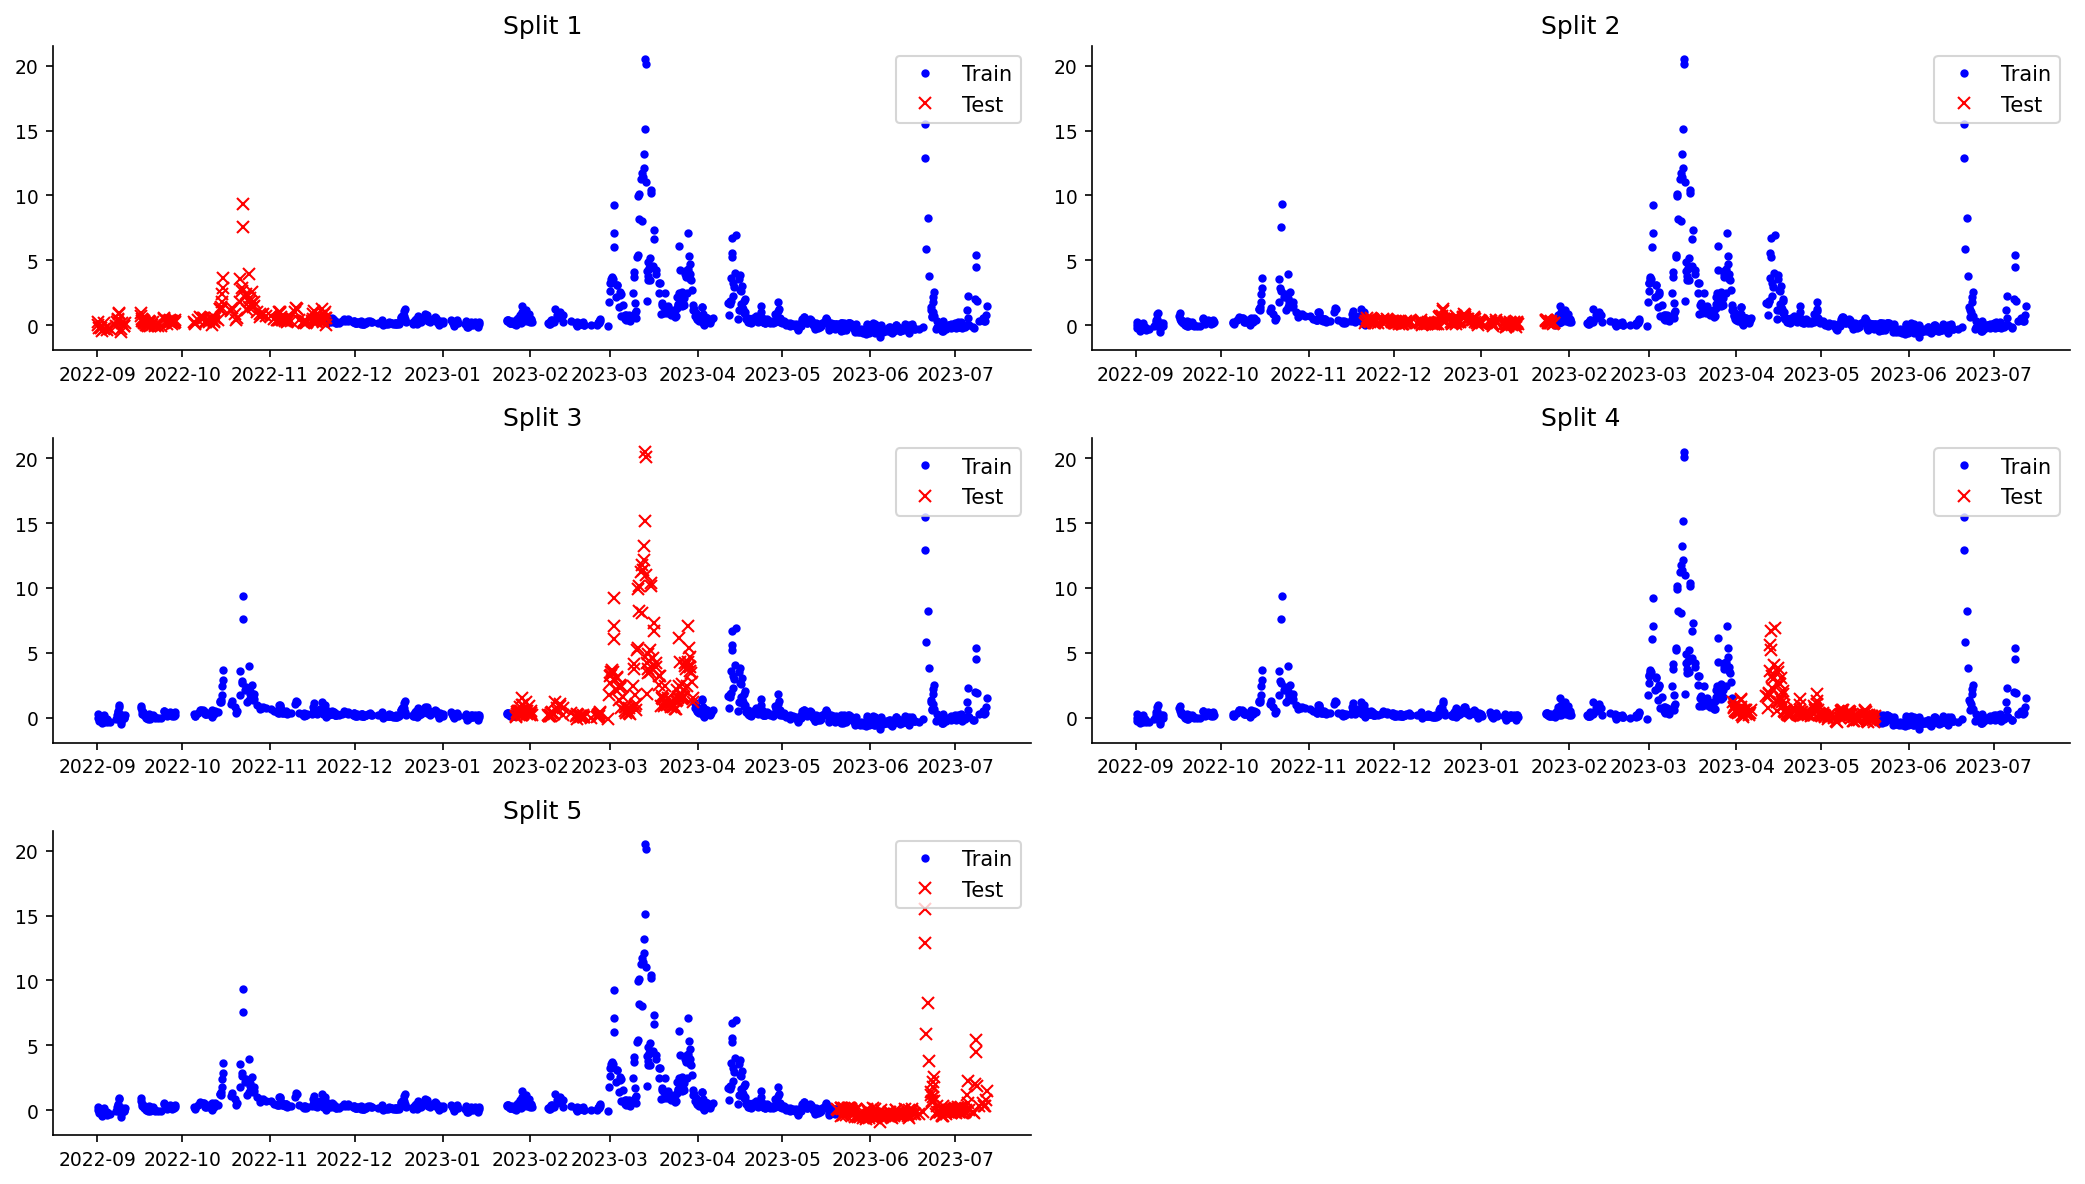

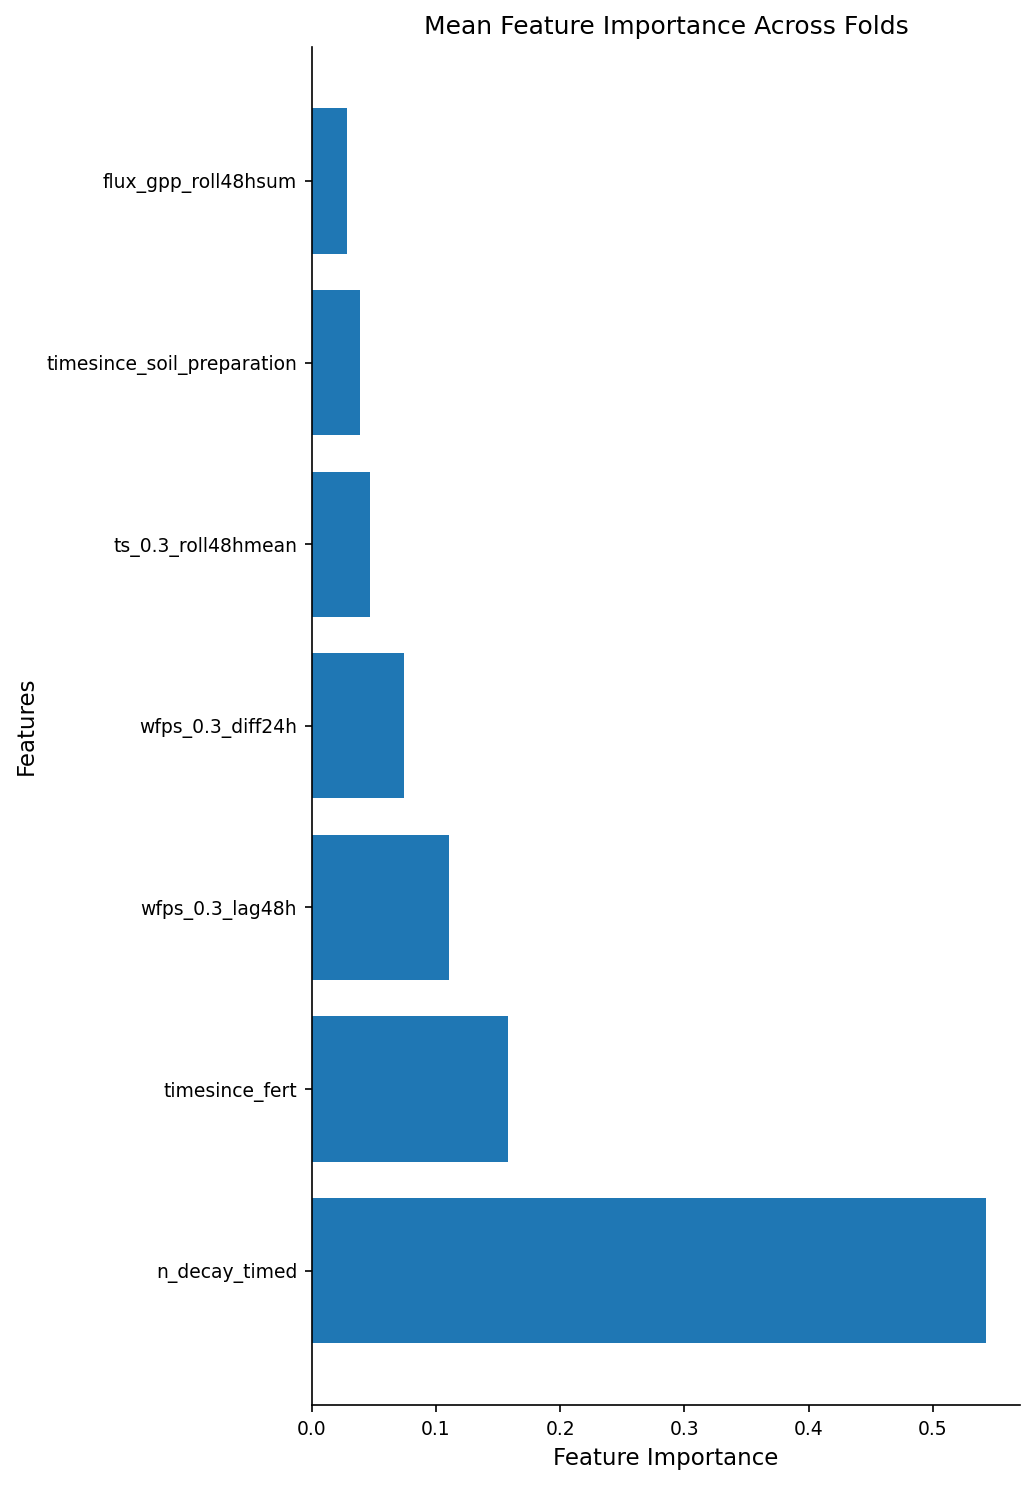

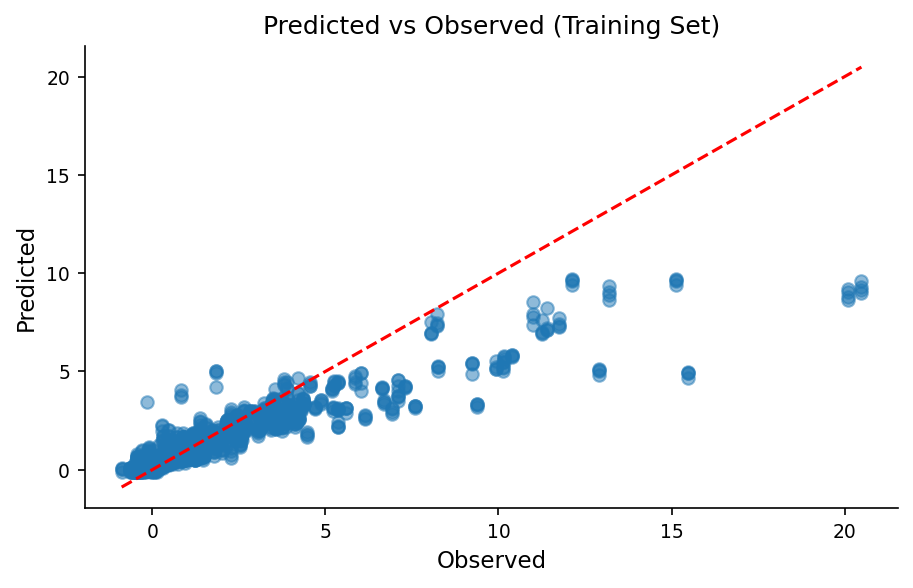

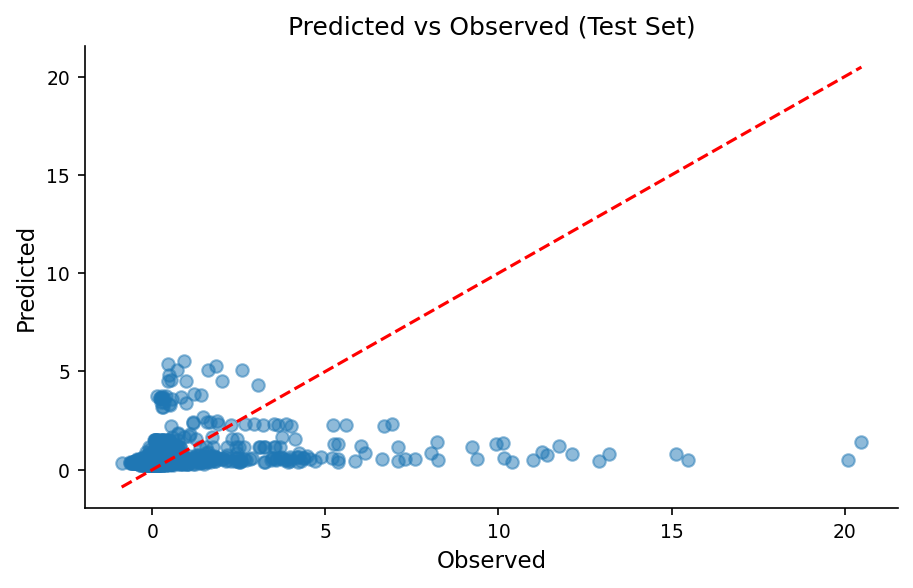

Train RMSE per fold: [1.1417 1.1877 0.7431 1.1181 1.0255]  |  Mean: 1.0432
Train MAE per fold: [0.5204 0.5621 0.3004 0.5069 0.4827]  |  Mean: 0.4745
Train R2 per fold: [0.7548 0.7433 0.6411 0.7642 0.7742]  |  Mean: 0.7355
Test RMSE per fold: [1.1279 0.7415 3.9951 1.5769 1.8297]  |  Mean: 1.8542
Test MAE per fold: [0.5349 0.6479 2.1997 0.9586 0.8626]  |  Mean: 1.0407
Test R2 per fold: [ -0.0343 -12.5074  -0.2715  -0.9165   0.022 ]  |  Mean: -2.7416


In [194]:
def create_splits(X, y, n_folds):
    splitter = KFold(n_splits=n_folds, shuffle=False)
    return list(splitter.split(X, y))

def compute_metrics(y_true, y_pred):
    return {
        'rmse': root_mean_squared_error(y_true, y_pred),
        'mae':  float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))),
        'r2':   r2_score(y_true, y_pred),
    }

X_cv = data_train.drop(columns=TARGET)
y_cv = data_train[TARGET]
splits = create_splits(X_cv, y_cv, N_FOLDS)

# --- visualise splits ---
n_rows = math.ceil(N_FOLDS / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()
for i, (tr_idx, te_idx) in enumerate(splits):
    axes[i].plot(y_cv.iloc[tr_idx].index, y_cv.iloc[tr_idx], '.', color='blue',  label='Train')
    axes[i].plot(y_cv.iloc[te_idx].index, y_cv.iloc[te_idx], 'x', color='red',   label='Test')
    axes[i].set_title(f'Split {i+1}')
    axes[i].legend()
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

# --- cross-validate ---
metrics_train, metrics_test = [], []
feat_imp_folds = []
y_train_all, y_pred_train_all = [], []
y_test_all,  y_pred_test_all  = [], []

for tr_idx, te_idx in splits:
    X_tr, X_te = X_cv.iloc[tr_idx], X_cv.iloc[te_idx]
    y_tr, y_te = y_cv.iloc[tr_idx], y_cv.iloc[te_idx]
    model.fit(X_tr, y_tr)
    yp_tr = model.predict(X_tr)
    yp_te = model.predict(X_te)
    metrics_train.append(compute_metrics(y_tr, yp_tr))
    metrics_test.append(compute_metrics(y_te, yp_te))
    feat_imp_folds.append(model.feature_importances_)
    y_train_all.extend(y_tr); y_pred_train_all.extend(yp_tr)
    y_test_all.extend(y_te);  y_pred_test_all.extend(yp_te)

# --- feature importance ---
feat_imp = np.nanmean(feat_imp_folds, axis=0)
order = np.argsort(-feat_imp)
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(X_cv.columns[order], feat_imp[order])
ax.set_xlabel('Feature Importance'); ax.set_ylabel('Features')
ax.set_title('Mean Feature Importance Across Folds')
plt.tight_layout(); plt.show()

# --- pred vs obs ---
for label, y_obs, y_pred in [('Training', y_train_all, y_pred_train_all),
                               ('Test',     y_test_all,  y_pred_test_all)]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(y_obs, y_pred, alpha=0.5, label=label)
    ax.plot([min(y_obs), max(y_obs)], [min(y_obs), max(y_obs)], 'r--')
    ax.set_xlabel('Observed'); ax.set_ylabel('Predicted')
    ax.set_title(f'Predicted vs Observed ({label} Set)')
    plt.show()

# --- print metrics ---
for split_name, m_list in [('Train', metrics_train), ('Test', metrics_test)]:
    for metric in ('rmse', 'mae', 'r2'):
        vals = [m[metric] for m in m_list]
        print(f'{split_name} {metric.upper()} per fold: {np.array(vals).round(4)}  |  Mean: {np.mean(vals):.4f}')


# MODEL EVALUATION

Training  R²=0.7588  RMSE=1.0433  MAE=0.4707
Test  R²=0.3587  RMSE=1.1901  MAE=0.7110


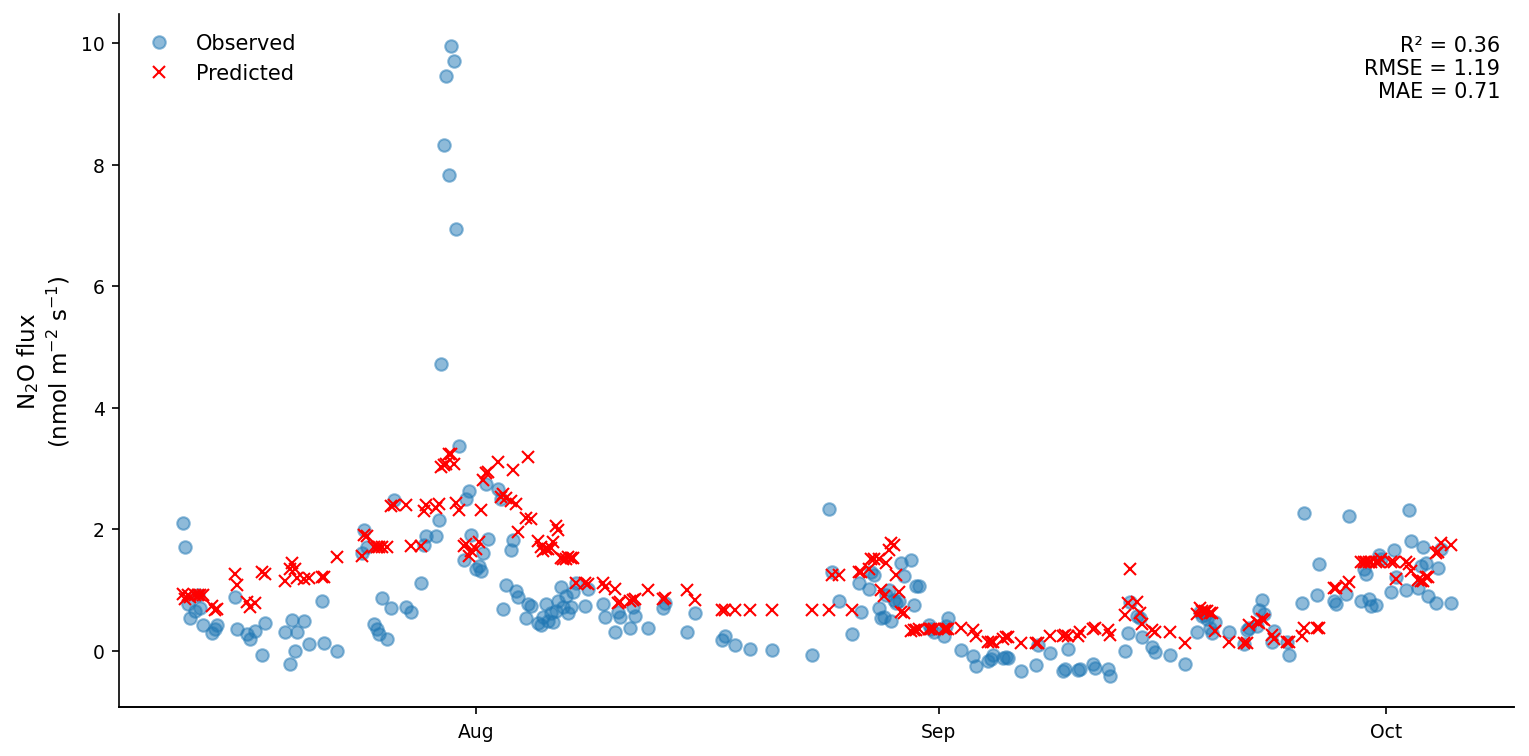

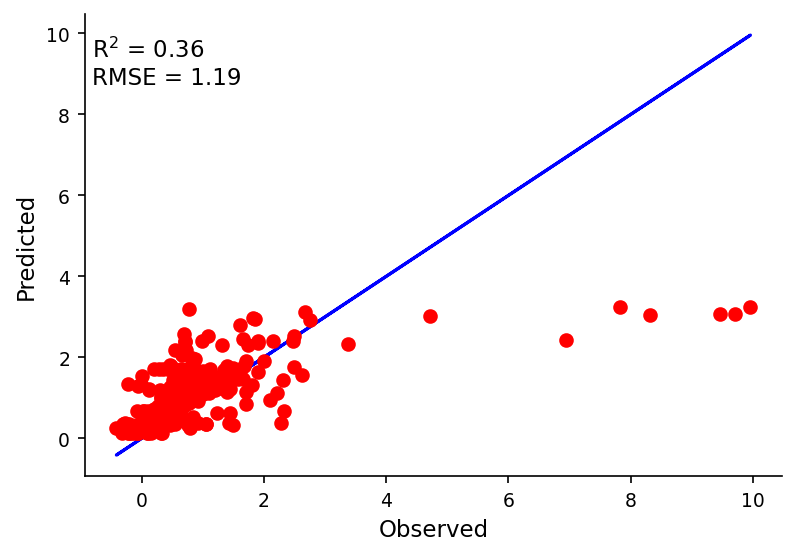

In [195]:
X_train, X_test = data_train.drop(columns=TARGET), data_test.drop(columns=TARGET)
y_train, y_test = data_train[TARGET], data_test[TARGET]

model.fit(X_train, y_train)
pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

for split_name, y_true, y_pred in [('Training', y_train, pred_train), ('Test', y_test, pred_test)]:
    m = compute_metrics(y_true, y_pred)
    print(f"{split_name}  R²={m['r2']:.4f}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}")

# --- time-series ---
r2_test   = r2_score(y_test, pred_test)
rmse_test = root_mean_squared_error(y_test, pred_test)
mae_test  = float(np.mean(np.abs(np.asarray(y_test) - pred_test)))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_test.index, y_test, 'o', alpha=0.5, label='Observed')
ax.plot(y_test.index, pred_test, 'rx', label='Predicted')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
secax.tick_params(axis='x', length=0, pad=30)
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}\nMAE = {mae_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel('N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$)')
ax.legend(frameon=False, loc='upper left')
plt.savefig('../figures/model_performance_test.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

# --- obs vs pred scatter ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(y_test, y_test, 'b-')
ax.plot(y_test, pred_test, 'ro')
ax.text(0.01, 0.95, f'R$^{{2}}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel('Observed'); ax.set_ylabel('Predicted')
plt.show()


# SHAP ANALYSIS
## Train model on full dataset

In [208]:
X = data[selected_features]
y = data[TARGET]
model.fit(X, y)

pred_all = model.predict(X)
m = compute_metrics(y, pred_all)
print(f"Full dataset  R²={m['r2']:.4f}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}")


Full dataset  R²=0.7544  RMSE=0.9976  MAE=0.4612


## Run SHAP

In [220]:
# Background: undisturbed conditions (no recent fertilisation or soil preparation)
bg_cols = ['timesince_soil_preparation', 'timesince_fert']
background_dataset = data_complete.loc[
    data_complete[bg_cols].eq(30).all(axis=1), selected_features
]

explainer = shap.TreeExplainer(model, data=background_dataset)

X_full     = data_complete[selected_features]
shap_values = explainer(X_full, check_additivity=True)
print('Baseline (expected value):', explainer.expected_value)


 99%|===================| 2367/2398 [00:41<00:00]        

Baseline (expected value): 0.4499738700709032


## Summary plot

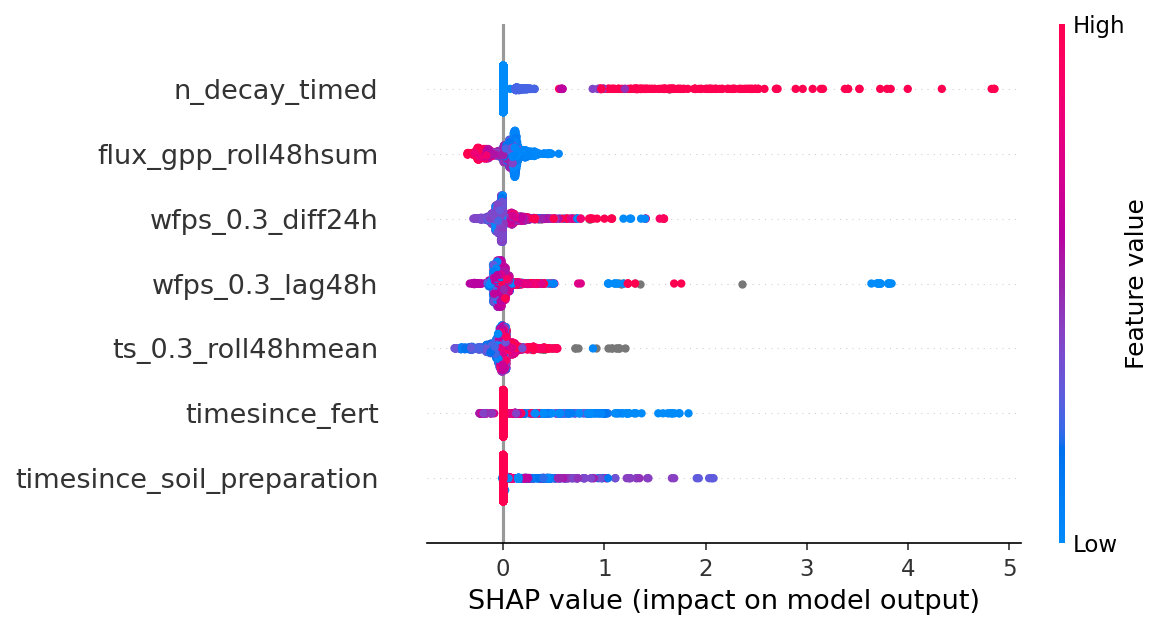

In [221]:
fig = plt.figure()
shap.summary_plot(shap_values, X_full, show=False)
fig.savefig('../figures/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Restructure and pool SHAP dataframe

In [222]:
shap_df = pd.DataFrame(shap_values.values, index=X_full.index, columns=X_full.columns)

# Pool fertilisation variables
fert_cols = [c for c in shap_df.columns if c.startswith('n_decay') or 'fert' in c]
shap_df['fertilization'] = shap_df[fert_cols].sum(axis=1)
shap_df.drop(columns=fert_cols, inplace=True)

# Pool WFPS variables
wfps_cols = [c for c in shap_df.columns if c.startswith('wfps')]
shap_df['wfps'] = shap_df[wfps_cols].sum(axis=1)
shap_df.drop(columns=wfps_cols, inplace=True)

rename_dict = {
    next(c for c in shap_df.columns if 'fertilization' in c):        'N fertilization',
    next(c for c in shap_df.columns if 'gpp' in c):                  'GPP',
    next(c for c in shap_df.columns if 'wfps' in c):                 'WFPS',
    next(c for c in shap_df.columns if 'timesince_soil_prep' in c):  'Soil disturbance',
    next(c for c in shap_df.columns if c.startswith('ts')):          'Soil T',
}
shap_df.rename(columns=rename_dict, inplace=True)
shap_df = shap_df[['N fertilization', 'WFPS', 'GPP', 'Soil disturbance', 'Soil T']]

## Normalisation and aggregation

In [223]:
aggregation_period = 'D'

shap_df_norm     = shap_df.div(shap_df.abs().sum(axis=1), axis=0)
shap_df_agg      = shap_df.resample(aggregation_period).mean()
shap_df_agg_norm = shap_df_agg.div(shap_df_agg.abs().sum(axis=1), axis=0)

## Plotting configuration

In [224]:
highlight_start = pd.Timestamp('2022-10-06')
highlight_end   = pd.Timestamp('2023-07-15')

event_lines = [
    {'date': '2022-10-06', 'color': '#003366', 'linestyle': ':',  'label': 'sowing'},
    {'date': '2023-07-15', 'color': '#003366', 'linestyle': '--', 'label': 'harvest'},
    {'date': '2023-02-26', 'color': '#F2C744', 'linestyle': '-',  'label': None},
    {'date': '2023-02-28', 'color': '#F2C744', 'linestyle': '-',  'label': 'N fert'},
    {'date': '2023-04-06', 'color': '#F2C744', 'linestyle': '-',  'label': 'N fert'},
]

palette = ['#882255', '#0072B2', '#009E73', '#A6761D', '#FDAE61']

fn2o_agg       = data_complete[TARGET].resample(aggregation_period).mean()
fn2o_preds     = pd.Series(model.predict(X_full), index=X_full.index)
fn2o_preds_agg = fn2o_preds.resample(aggregation_period).mean()
gpp_agg        = data_complete['flux_gpp'].resample(aggregation_period).mean()


## Plotting functions

In [225]:
def _add_x_date_formatting(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    secax = ax.secondary_xaxis('bottom')
    secax.xaxis.set_major_locator(mdates.YearLocator())
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    secax.tick_params(axis='x', length=0, pad=30)

def _add_shading(ax, df_index):
    ax.axvspan(df_index.min(), highlight_start, color='gray', alpha=0.3, zorder=0)
    ax.axvspan(highlight_end,  df_index.max(),  color='gray', alpha=0.3, zorder=0)


def plot_shap_timeseries(df, shading=True, fn2o_observed=None, fn2o_predicted=None,
                         width=1, start_date=None, end_date=None, ax1=None, ylim=(-1.1, 1.1)):
    if start_date or end_date:
        df = df.loc[start_date:end_date]
        if fn2o_observed  is not None: fn2o_observed  = fn2o_observed.loc[start_date:end_date]
        if fn2o_predicted is not None: fn2o_predicted = fn2o_predicted.loc[start_date:end_date]

    shap_pos = df.clip(lower=0)
    shap_neg = df.clip(upper=0)

    for sign_df, label_flag in [(shap_pos, True), (shap_neg, False)]:
        bottom = None
        for idx, col in enumerate(sign_df.columns):
            ax1.bar(sign_df.index, sign_df[col], bottom=bottom,
                    label=col if label_flag else None,
                    color=palette[idx], width=width)
            bottom = sign_df[col] if bottom is None else bottom + sign_df[col]

    if shading:
        _add_shading(ax1, df.index)

    ax2 = None
    if fn2o_observed is not None or fn2o_predicted is not None:
        ax2 = ax1.twinx()
        if fn2o_observed is not None:
            ax2.plot(fn2o_observed.index, fn2o_observed, color='white', marker='x',
                     linestyle='none', linewidth=1.5, label='measured N$_2$O flux')
        if fn2o_predicted is not None:
            ax2.plot(fn2o_predicted.index, fn2o_predicted, color='pink', linestyle='-',
                     linewidth=1.5)
        y2_max = 15
        ax2.set_ylim(-y2_max, y2_max)
        ax2.set_yticks([t for t in ax2.get_yticks() if 0 <= t <= 10])
        ax2.set_ylabel('N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$)')
        ax2.yaxis.set_label_coords(1.03, 0.75)

    if ylim is not None:
        ax1.set_ylim(ylim)
    ax1.set_ylabel('Relative contribution')
    ax1.legend(bbox_to_anchor=(1, 0.25), frameon=False, loc='center left')
    ax1.set_xlim(df.index.min(), df.index.max())
    _add_x_date_formatting(ax1)
    return ax1, ax2


def plot_flux_timeseries(flux_n2o, flux_gpp, linestyle='-', linewidth=3,
                         figsize=(12, 4), ax=None, scale_gpp=0.5):
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    ax.plot(flux_n2o.index, flux_n2o.values, color='black', linestyle=linestyle,
            linewidth=linewidth, label='N$_2$O flux')

    ax2 = ax.twinx()
    ax2.plot(flux_gpp.index, flux_gpp.values * scale_gpp, color='#009E73',
             linestyle=linestyle, linewidth=linewidth, label='GPP')
    true_ticks = np.arange(0, 21, 5)
    ax2.set_yticks(true_ticks * scale_gpp)
    ax2.set_yticklabels(str(t) for t in true_ticks)
    ax2.set_ylim(0, 22 * scale_gpp)
    ax2.set_ylabel('GPP\n(µmol m$^{-2}$ s$^{-1}$)')

    for event in event_lines:
        event_date = pd.to_datetime(event['date'])
        ax.annotate(event['label'],
                    xy=(mdates.date2num(event_date), 0.7),
                    xytext=(mdates.date2num(event_date), 0.9),
                    xycoords=('data', 'axes fraction'),
                    textcoords=('data', 'axes fraction'),
                    ha='center', va='bottom', color='black',
                    arrowprops=dict(arrowstyle='-|>', color=event['color'], lw=1.5),
                    annotation_clip=False)

    _add_shading(ax, flux_n2o.index)
    ax.set_ylabel('N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$)')
    ax.tick_params(axis='x', bottom=True, labelbottom=False)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, loc='upper right', frameon=False)
    return ax


def plot_shap_heatmap(shap_df, cmap='coolwarm', figsize=(16, 6),
                      label='Relative contribution', ax=None, cax=None):
    shap_df   = shap_df[shap_df.columns[::-1]].copy()
    features  = shap_df.columns
    data      = shap_df.T.values
    date_nums = mdates.date2num(shap_df.index)
    X_mesh, Y_mesh = np.meshgrid(
        np.append(date_nums, date_nums[-1] + 1),
        np.arange(len(features) + 1)
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    pcm = ax.pcolormesh(X_mesh, Y_mesh, data, cmap=cmap, shading='auto',
                        vmin=-np.max(np.abs(data)), vmax=np.max(np.abs(data)))
    ax.set_yticks(np.arange(len(features)) + 0.5)
    ax.set_yticklabels(features)
    ax.xaxis_date()
    _add_x_date_formatting(ax)
    fig.colorbar(pcm, ax=ax if cax is None else None, cax=cax, label=label)
    return ax


def make_composite_figure(fn2o_agg, gpp_agg, shap_df_bar, shap_df_heat,
                           bar_label=None, heat_label='Relative contribution',
                           ylim=(-1.1, 1.1), fn2o_predicted=None,
                           savepath_bar=None, savepath_heat=None):

    plt.rcParams.update({'font.size': 14})

    # ── stacked-bar figure ───
    fig = plt.figure(figsize=(16, 9))
    gs  = GridSpec(2, 1, height_ratios=[1, 2], hspace=0.05)
    ax_flux = fig.add_subplot(gs[0])
    ax_shap = fig.add_subplot(gs[1], sharex=ax_flux)
    ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', va='top')
    ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', va='top')
    plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
    plot_shap_timeseries(df=shap_df_bar, fn2o_predicted=fn2o_predicted, ax1=ax_shap, width=1, ylim=ylim)
    if bar_label:
        ax_shap.set_ylabel(bar_label)
    fig.align_ylabels(fig.axes)
    if savepath_bar:
        plt.savefig(savepath_bar, dpi=300, bbox_inches='tight')
    plt.show()

    # ── heatmap figure ───
    fig = plt.figure(figsize=(16, 8))
    gs  = GridSpec(2, 2, width_ratios=[20, 0.5], height_ratios=[1, 2], hspace=0, wspace=0.05)
    ax_flux = fig.add_subplot(gs[0, 0])
    ax_shap = fig.add_subplot(gs[1, 0], sharex=ax_flux)
    cax     = fig.add_subplot(gs[1, 1])
    ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', va='top')
    ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', va='top')
    plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
    plot_shap_heatmap(shap_df_heat, ax=ax_shap, cax=cax, label=heat_label)
    if savepath_heat:
        plt.savefig(savepath_heat, dpi=300, bbox_inches='tight')
    plt.show()

## Time-series plots
### Normalised

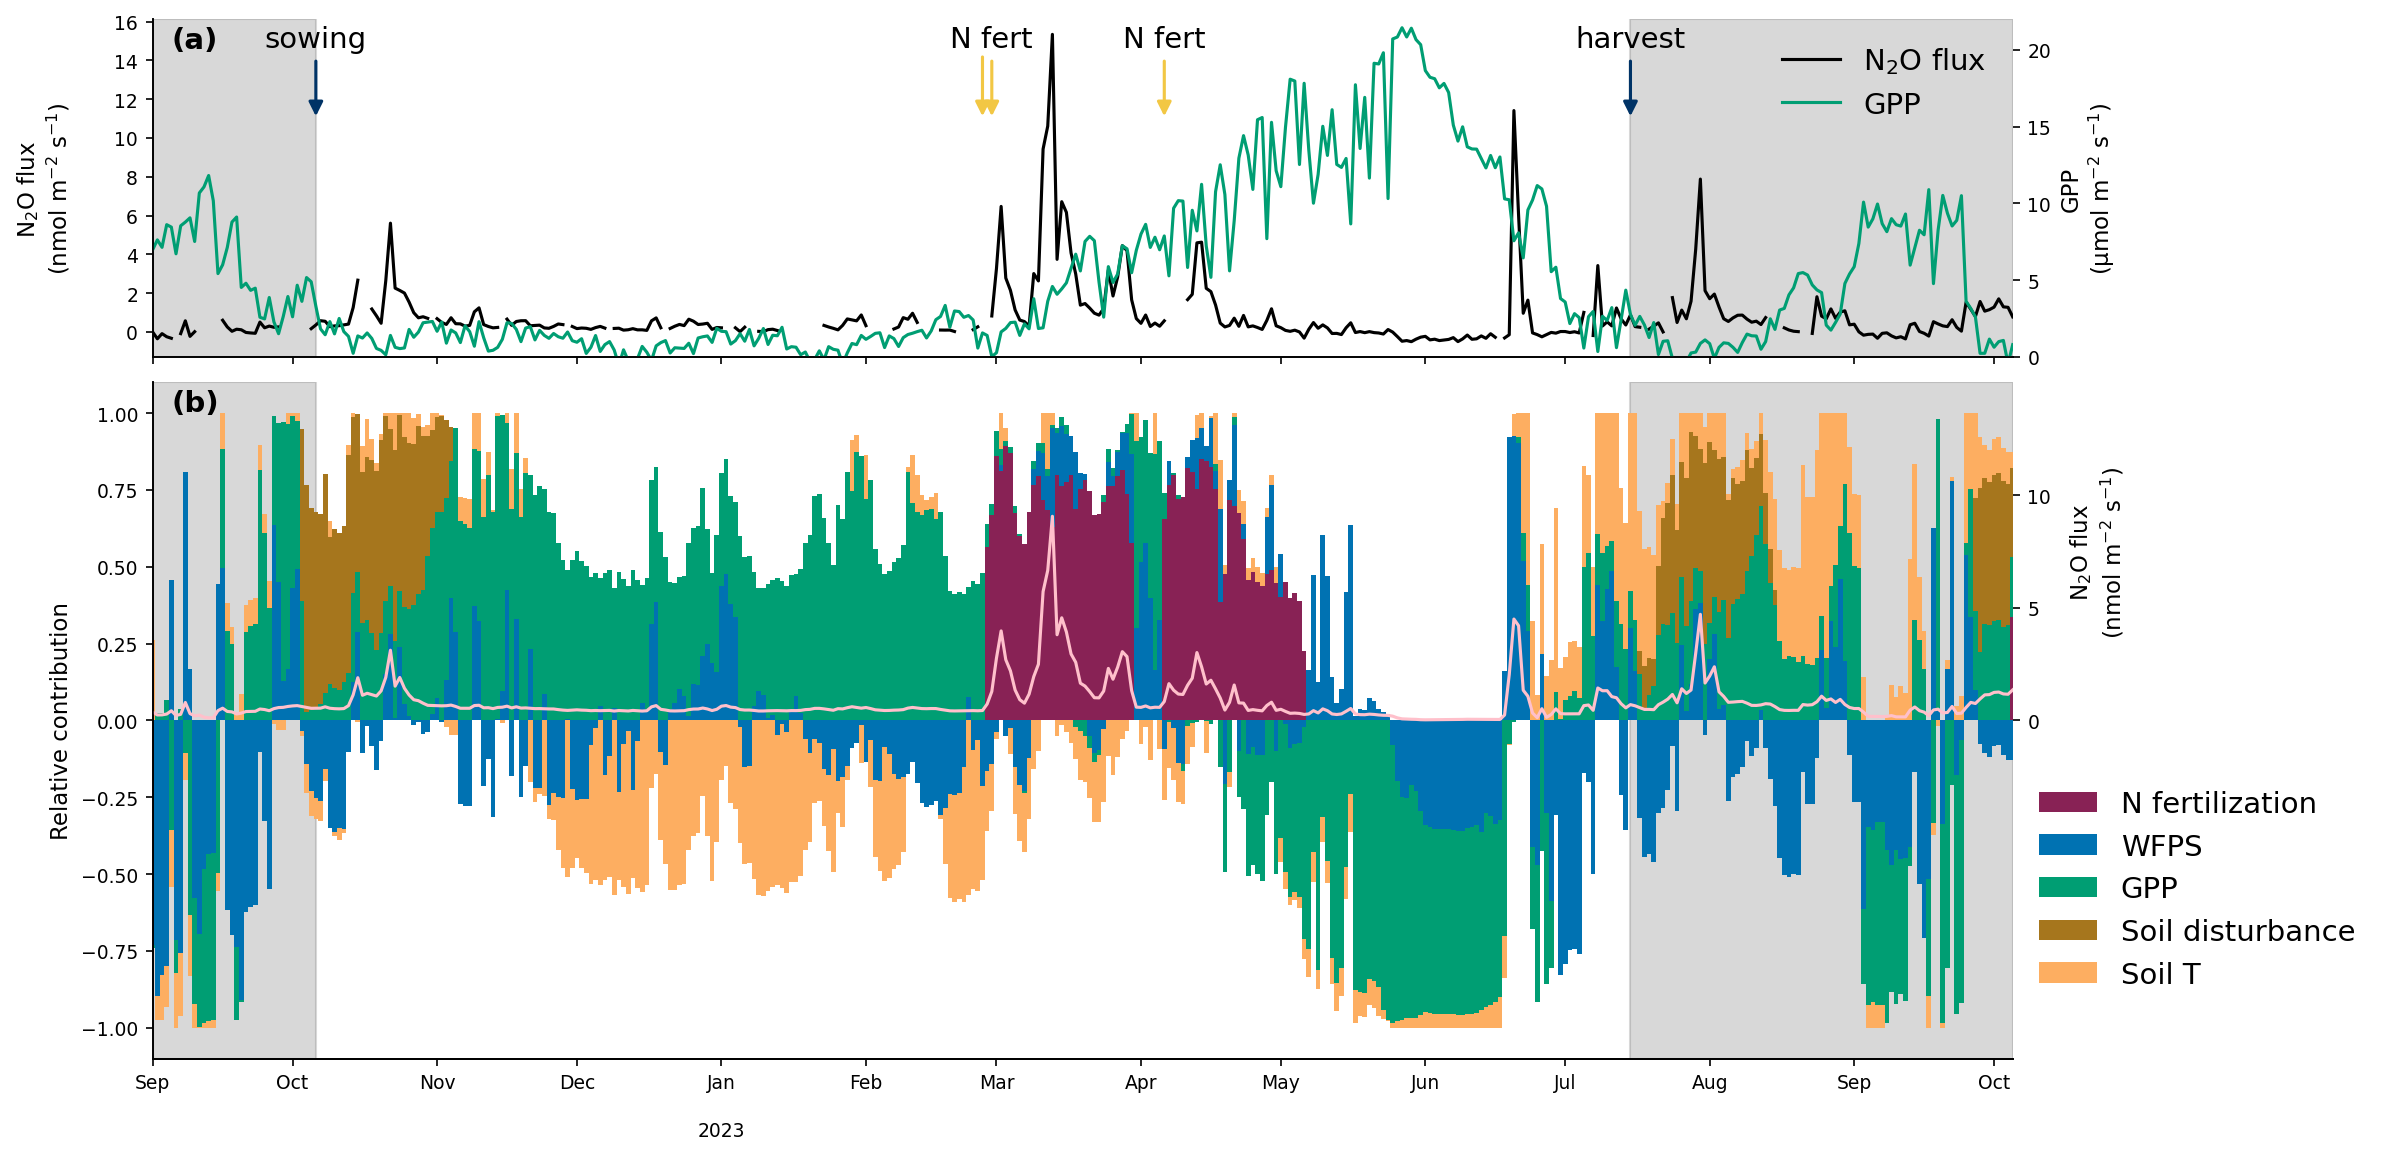

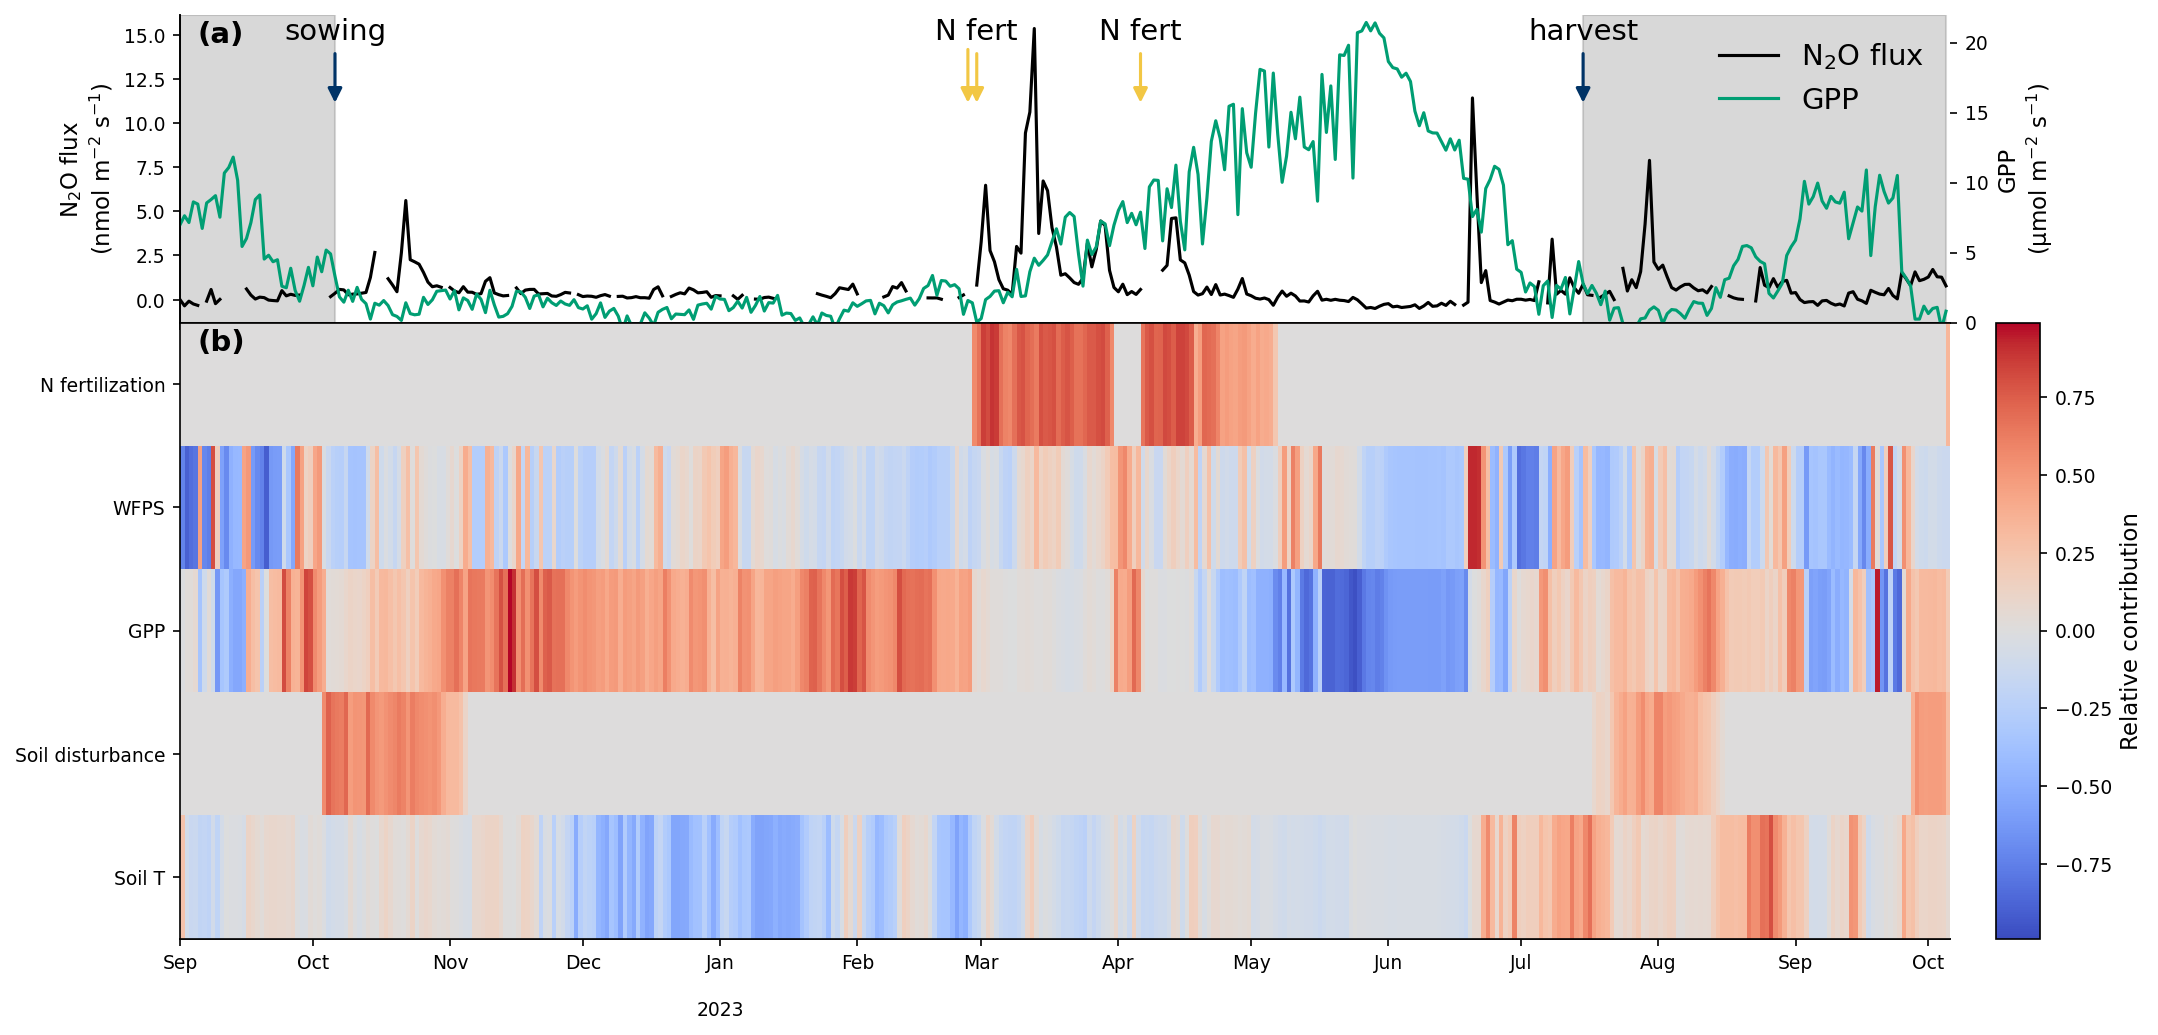

In [226]:
make_composite_figure(
    fn2o_agg, gpp_agg,
    shap_df_bar=shap_df_agg_norm, shap_df_heat=shap_df_agg_norm,
    ylim=(-1.1, 1.1),
    fn2o_predicted=fn2o_preds_agg,
    savepath_bar='../figures/shap_stacked_bar_normalized.png',
    savepath_heat='../figures/shap_heatmap_normalized.png',
)

### Standard (raw SHAP values)

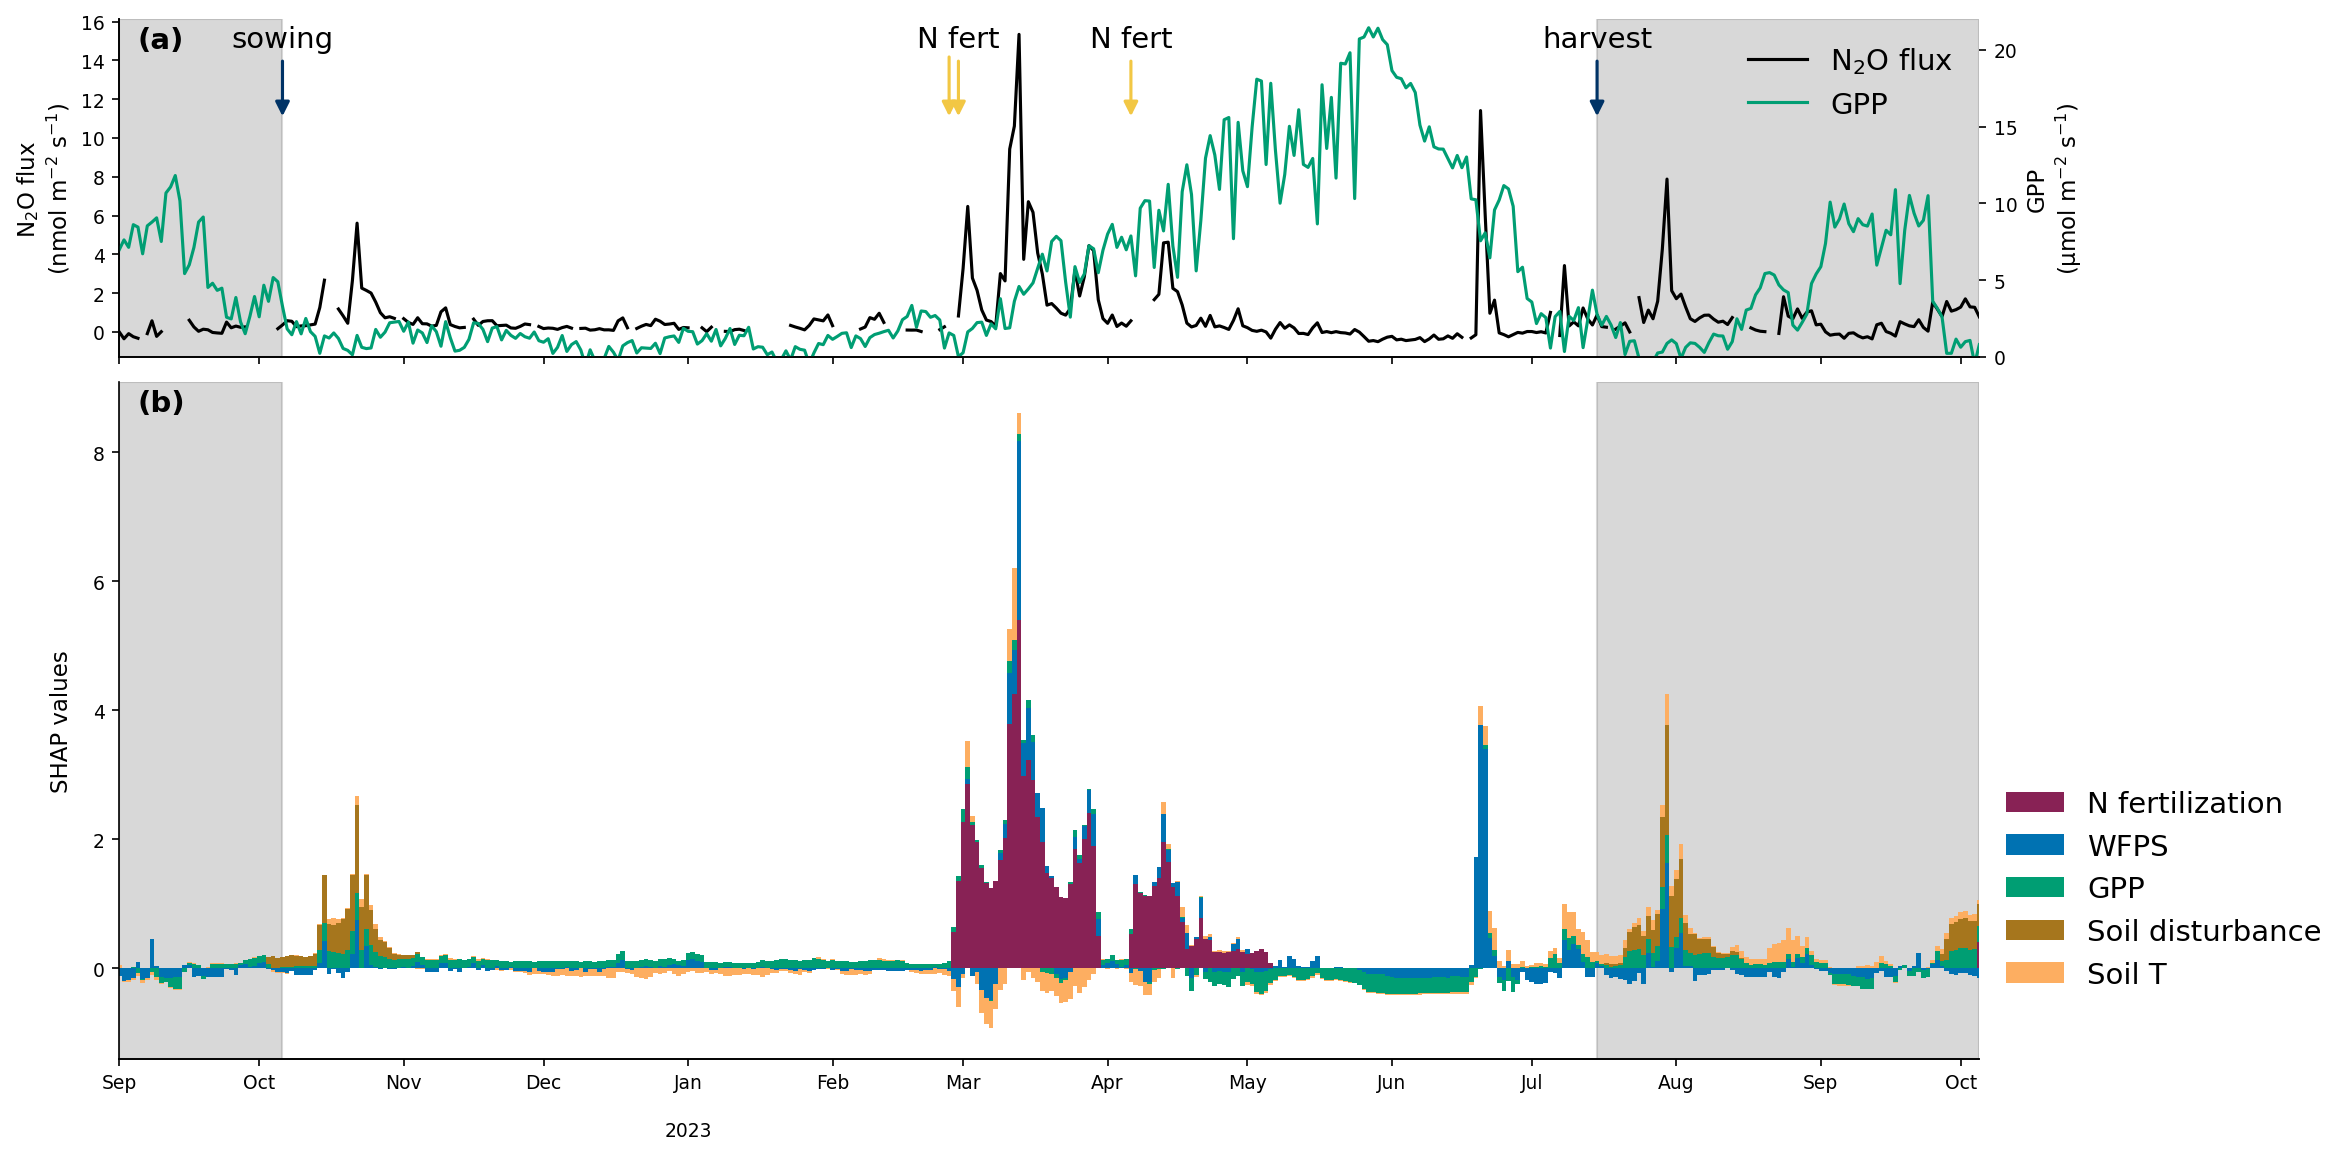

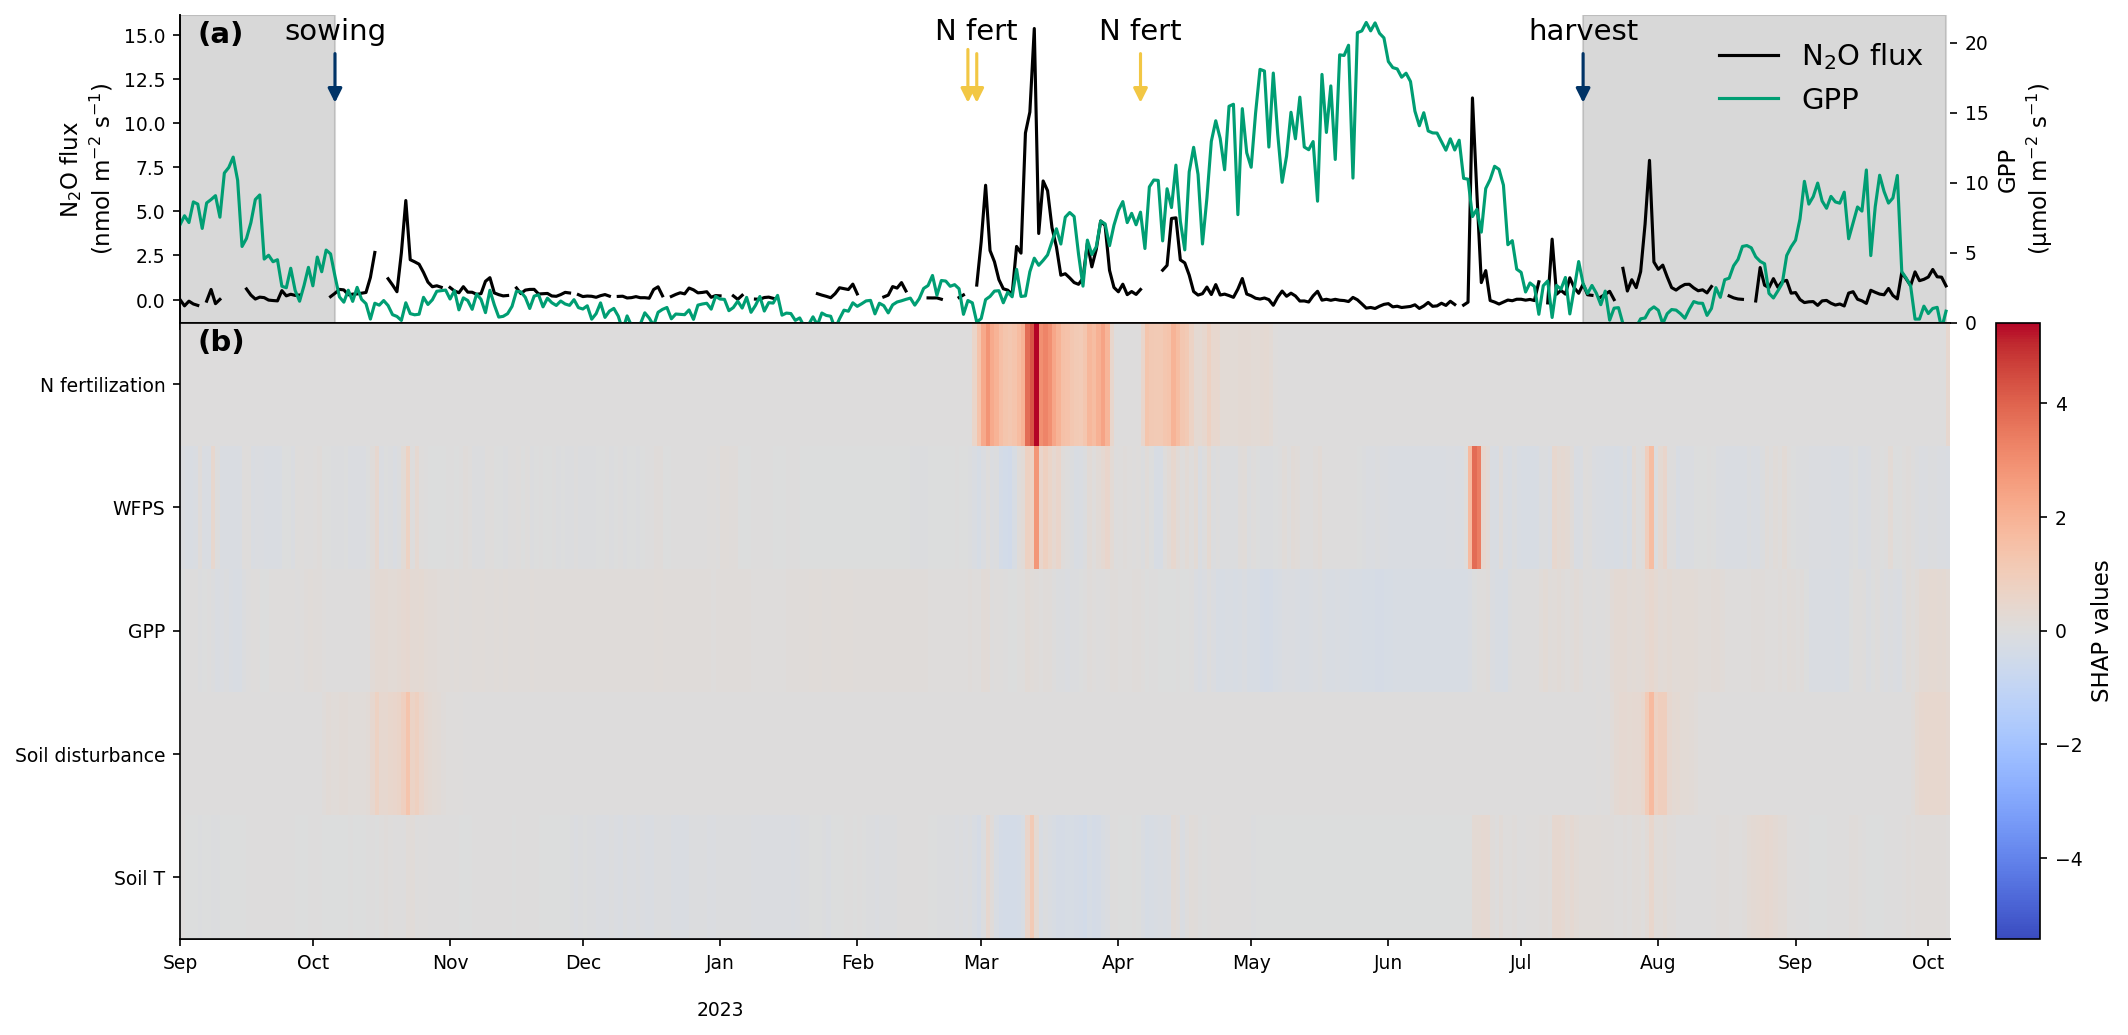

In [227]:
make_composite_figure(
    fn2o_agg, gpp_agg,
    shap_df_bar=shap_df_agg, shap_df_heat=shap_df_agg,
    bar_label='SHAP values', heat_label='SHAP values',
    ylim=None,
    savepath_bar='../figures/shap_stacked_bar_standard.png',
    savepath_heat='../figures/shap_heatmap_standard.png',
)

## Overall contributions

% positive contribution:
 N fertilization     43.219894
WFPS                18.558075
GPP                 16.829480
Soil disturbance    12.437859
Soil T               8.954692

% negative contribution:
 N fertilization      0.000000
WFPS                41.238112
GPP                 30.289389
Soil disturbance     0.003378
Soil T              28.469121


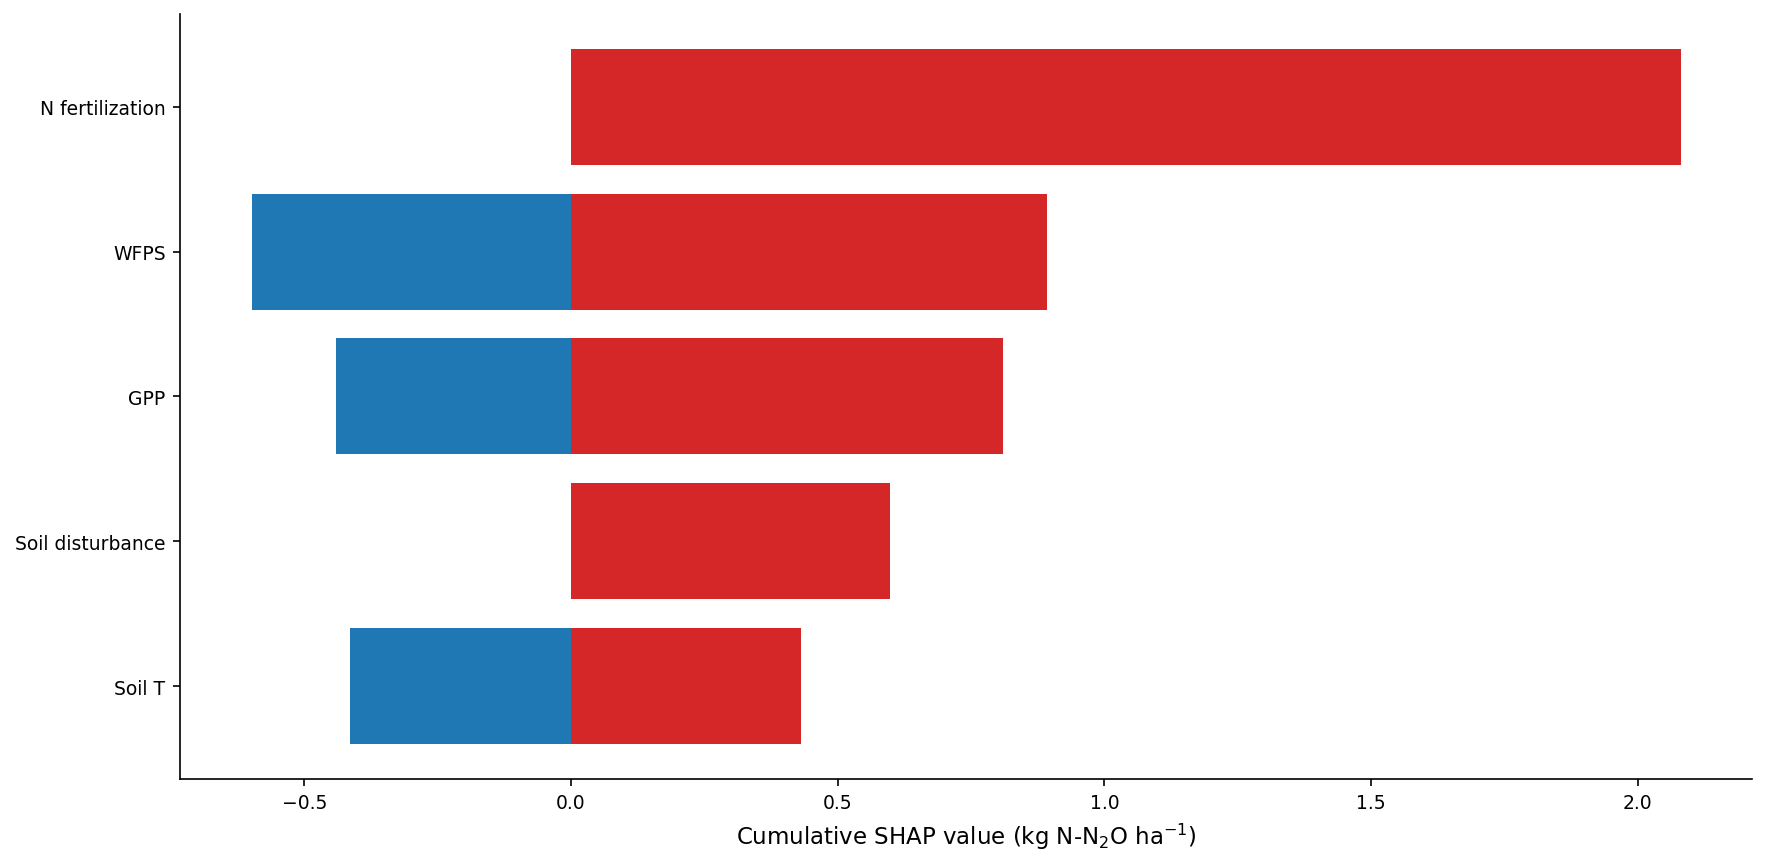

In [228]:
pos_pct = (shap_df[shap_df > 0].sum() / shap_df[shap_df > 0].sum().sum()) * 100
neg_pct = (shap_df[shap_df < 0].abs().sum() / shap_df[shap_df < 0].abs().sum().sum()) * 100
print('% positive contribution:\n', pos_pct.to_string())
print('\n% negative contribution:\n', neg_pct.to_string())

unit_factor = 60 * 60 * float(TIME_RESOLUTION) * 28.014 * 1e-9 * 1e-3 * 1e4
pos_sum = shap_df[shap_df > 0].sum() * unit_factor
neg_sum = shap_df[shap_df < 0].sum() * unit_factor
contrib_df = pd.concat([pos_sum.rename('Positive'), neg_sum.rename('Negative')], axis=1).fillna(0)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(contrib_df.index, contrib_df['Negative'], color='#1f77b4')
ax.barh(contrib_df.index, contrib_df['Positive'], color='#d62728')
ax.invert_yaxis()
ax.set_xlabel('Cumulative SHAP value (kg N-N$_{2}$O ha$^{-1}$)')
plt.tight_layout()
plt.savefig('../figures/shap_contributions_summary.png', dpi=300, bbox_inches='tight')
plt.show()


## SHAP dependence scatterplots

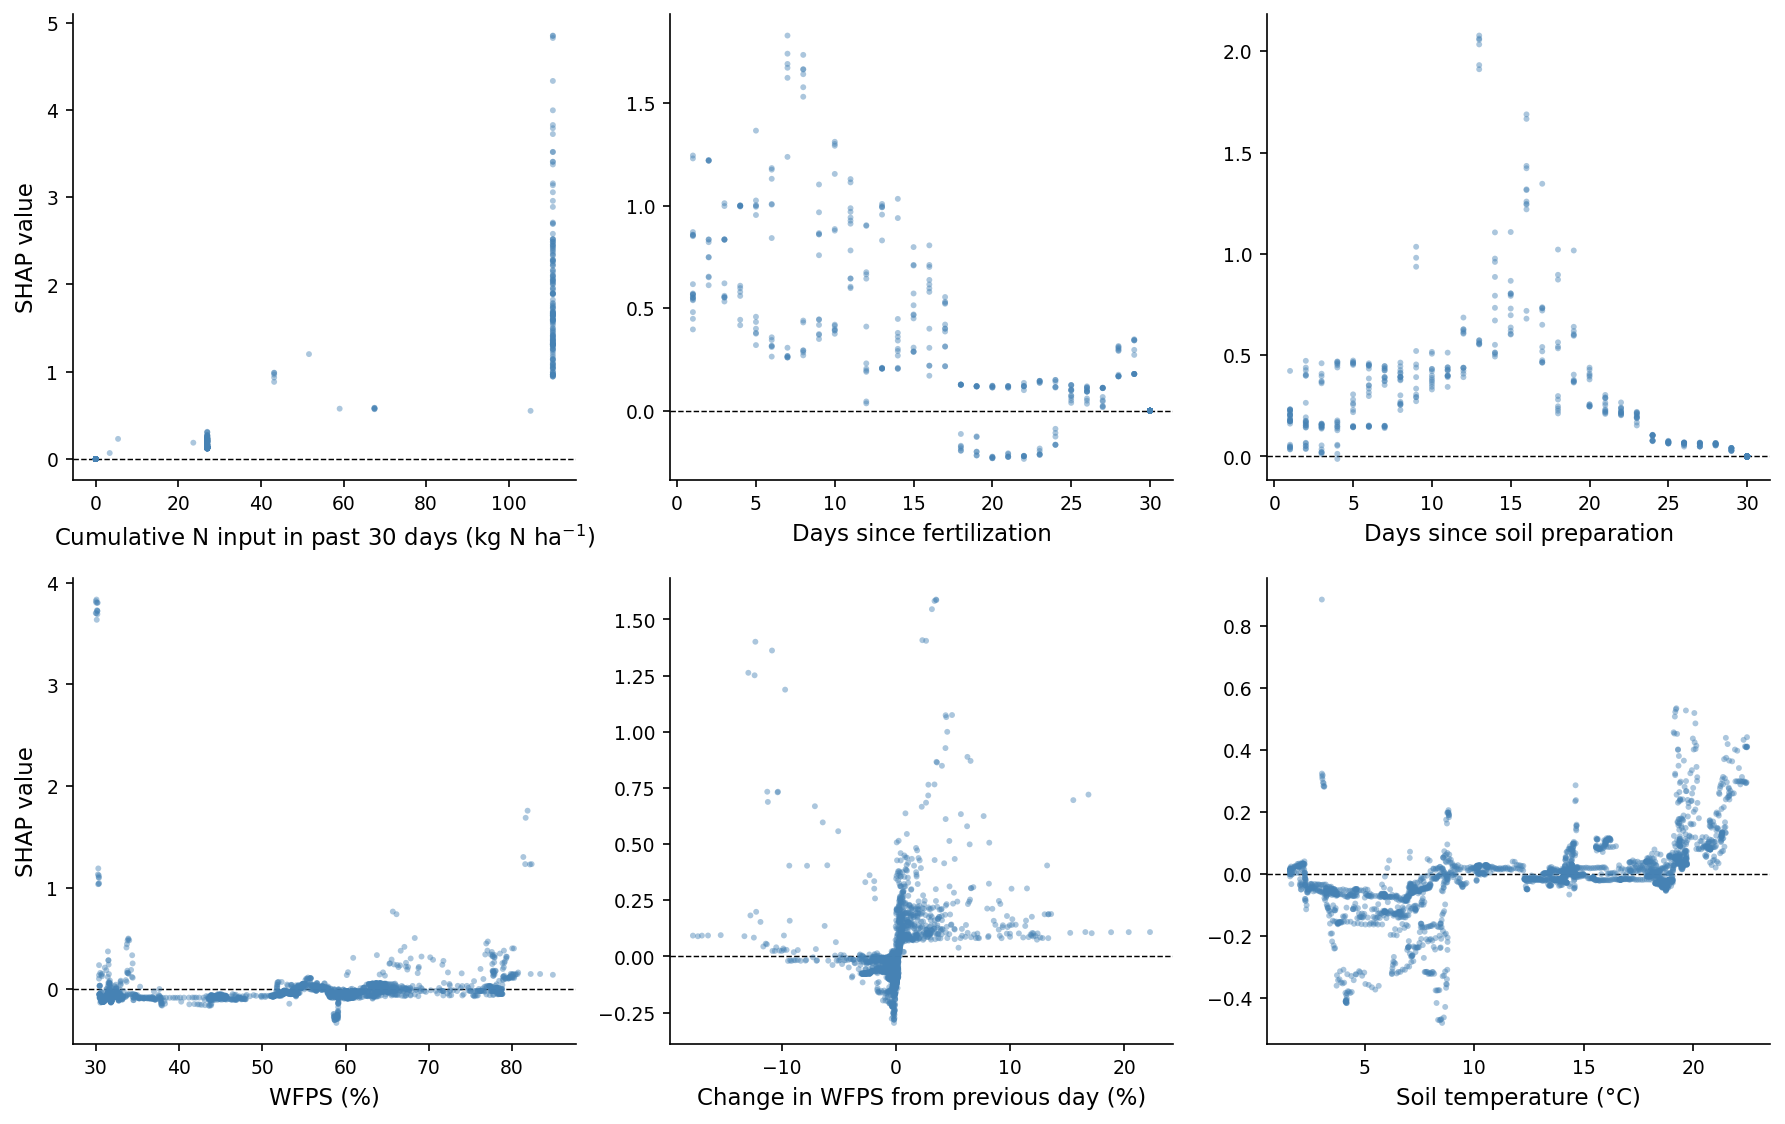

In [229]:
label_map = {
    'flux_gpp_roll48hsum':        r'GPP (µmol m$^{-2}$ s$^{-1}$)',
    'wfps_0.3_lag48h':            'WFPS (%)',
    'wfps_0.3_diff24h':           'Change in WFPS from previous day (%)',
    'timesince_soil_preparation': 'Days since soil preparation',
    'timesince_fert':             'Days since fertilization',
    'ts_0.3_roll48hmean':         'Soil temperature (°C)',
    'n_decay_timed':              r'Cumulative N input in past 30 days (kg N ha$^{-1}$)',
}

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 150,
})

cols      = [v for v in X_full.columns if v != 'flux_gpp_roll48hsum']
ncols     = 3
nrows     = math.ceil(len(cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.8))
axes_flat = axes.flatten()

for i, var in enumerate(cols):
    ax        = axes_flat[i]
    feat_vals = X_full[var].values
    shap_vals = shap_values.values[:, X_full.columns.get_loc(var)]

    ax.scatter(feat_vals, shap_vals, color='steelblue', edgecolors='none',
               alpha=0.45, s=8, zorder=2)
    ax.axhline(0, color='k', lw=0.7, linestyle='dashed', zorder=1)
    ax.set_xlabel(label_map.get(var, var))
    ax.set_ylabel('SHAP value' if i % ncols == 0 else '')

for j in range(len(cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/SHAP_dependence_no_gpp.png', dpi=300, bbox_inches='tight')
plt.show()

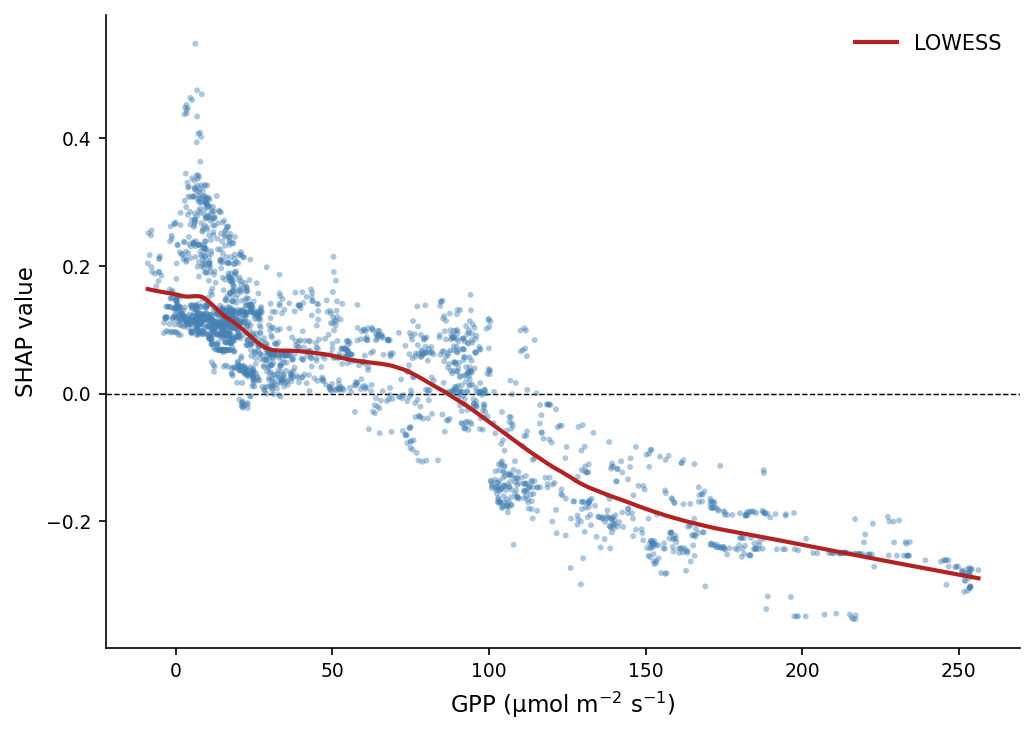

In [230]:
gpp_vals  = X_full['flux_gpp_roll48hsum'].values
shap_gpp  = shap_values.values[:, X_full.columns.get_loc('flux_gpp_roll48hsum')]
smooth    = lowess(shap_gpp, gpp_vals, frac=0.3, return_sorted=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(gpp_vals, shap_gpp, color='steelblue', edgecolors='none',
           alpha=0.45, s=8, zorder=2)
ax.plot(smooth[:, 0], smooth[:, 1], color='firebrick', lw=2, zorder=3, label='LOWESS')
ax.axhline(0, color='k', lw=0.7, linestyle='dashed', zorder=1)
ax.set_xlabel(label_map.get('flux_gpp_roll48hsum'))
ax.set_ylabel('SHAP value')
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('../figures/SHAP_GPP_dependence.png', dpi=300, bbox_inches='tight')
plt.show()